## Análise de Dados de Alugueis (RJ & SP)

In [1]:
#Importando as bibliotecas que serão utilizadas
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Importando os dados para a análise
dados = pd.read_csv('aluguel.csv', sep=';')
dados

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
...,...,...,...,...,...,...,...,...,...
32955,Quitinete,Centro,0,0,0,27,800.0,350.0,25.0
32956,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0
32957,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0
32958,Apartamento,Leblon,2,0,0,70,3000.0,760.0,NaN


## Análise dos dados

### Quantas linhas e colunas temos no DataFrame?

In [3]:
print('DIMENSÕES DO DATAFRAME:')
print(f'Linhas: {dados.shape[0]}')
print(f'Colunas: {dados.shape[1]}')

DIMENSÕES DO DATAFRAME:
Linhas: 32960
Colunas: 9


### Quais são os tipos de dados que temos?

In [4]:
dados.dtypes

Tipo           object
Bairro         object
Quartos         int64
Vagas           int64
Suites          int64
Area            int64
Valor         float64
Condominio    float64
IPTU          float64
dtype: object

### Verificaremos agora algumas informações do DataFrame

In [5]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32960 entries, 0 to 32959
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tipo        32960 non-null  object 
 1   Bairro      32960 non-null  object 
 2   Quartos     32960 non-null  int64  
 3   Vagas       32960 non-null  int64  
 4   Suites      32960 non-null  int64  
 5   Area        32960 non-null  int64  
 6   Valor       32943 non-null  float64
 7   Condominio  28867 non-null  float64
 8   IPTU        22723 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 2.3+ MB


In [6]:
#Como podemos observar, as nossas ultimas 3 variáveis (Valor, Condominio e IPTU), existem valores ausentes
dados.isnull().sum()

Tipo              0
Bairro            0
Quartos           0
Vagas             0
Suites            0
Area              0
Valor            17
Condominio     4093
IPTU          10237
dtype: int64

### Apagando e Preenchendo Dados Faltantes 

In [7]:
#Vamos eliminar as linhas da coluna 'Valor' que forem nulas
dados.dropna(subset = ['Valor'], inplace=True)

In [8]:
#Vamos eliminar também os imóveis do tipo 'Apartamento' que não apresentam valor 'Condominio'
selecao = (dados['Tipo'] == 'Apartamento') & (dados['Condominio'].isnull())
dados = dados[~selecao]
dados

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
...,...,...,...,...,...,...,...,...,...
32955,Quitinete,Centro,0,0,0,27,800.0,350.0,25.0
32956,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0
32957,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0
32958,Apartamento,Leblon,2,0,0,70,3000.0,760.0,NaN


Como vimos no início nosso DataFrame tinha 32960 entradas, porém depois de fazermos uma limpeza existem apenas 32198. Um total de 762 linhas a menos. Agora vamos preencher os valores nulos em 'Condominio' e 'IPTU'

In [9]:
#Vamos completar os valores ausentes com 0s
dados = dados.fillna({'Condominio': 0, 'IPTU': 0})
dados.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,0.0,0.0
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0


In [10]:
#Como apagamos algumas linhas, temos que fazer os índices novamente
dados.index = range(dados.shape[0])

### Váriaveis Que Possivelmente Apresentam Outliers

Text(0.5, 1.0, 'IPTU')

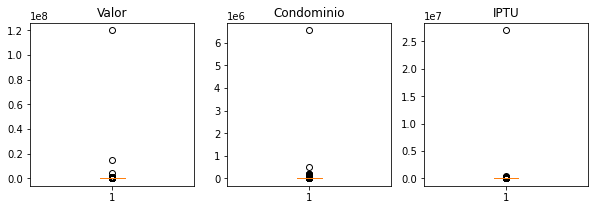

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(10,3))

axes[0].boxplot(dados['Valor'])
axes[0].set_title('Valor')

axes[1].boxplot(dados['Condominio'])
axes[1].set_title('Condominio')

axes[2].boxplot(dados['IPTU'])
axes[2].set_title('IPTU')

Como podemos observar, existem valores outliers

### Removendo Outliers

In [12]:
valor = dados['Valor']
condominio = dados['Condominio']
iptu = dados['IPTU']

In [13]:
#Vamos fazer os calculos na parte de estatística
Q1 = valor.quantile(.25)
Q3 = valor.quantile(.75)
IIQ = Q3 - Q1
lim1_inferior = Q1 - 1.5 * IIQ
lim3_superior = Q3 + 1.5 * IIQ

Q2 = condominio.quantile(.25)
Q4 = condominio.quantile(.75)
IIQ = Q4 - Q2
lim2_inferior = Q2 - 1.5 * IIQ
lim4_superior = Q4 + 1.5 * IIQ

Q5 = iptu.quantile(.25)
Q6 = iptu.quantile(.75)
IIQ = Q3 - Q1
lim5_inferior = Q1 - 1.5 * IIQ
lim6_superior = Q3 + 1.5 * IIQ

In [14]:
#Criando as seleções
selecao1 = (valor >= lim1_inferior) & (valor <= lim3_superior)
selecao2 = (condominio >= lim2_inferior) & (condominio <= lim4_superior)
selecao3 = (iptu >= lim5_inferior) & (iptu <= lim6_superior)

dados_new1 = dados[selecao1]
dados_new2 = dados[selecao2]
dados_new3 = dados[selecao3]
dados_gerais = (selecao1) & (selecao2) & (selecao3)
dados_new4 = dados[dados_gerais]

Text(0.5, 1.0, 'IPTU')

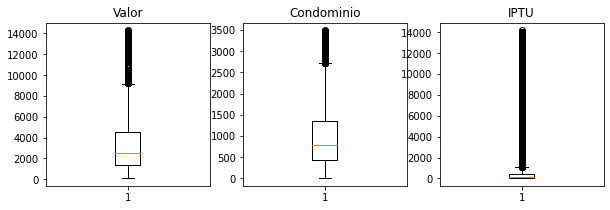

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(10,3))

axes[0].boxplot(dados_new1['Valor'])
axes[0].set_title('Valor')

axes[1].boxplot(dados_new2['Condominio'])
axes[1].set_title('Condominio')

axes[2].boxplot(dados_new3['IPTU'])
axes[2].set_title('IPTU')

### Comparação Do Antes e Depois

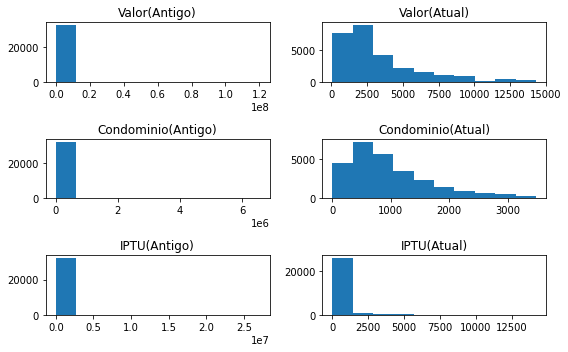

In [16]:
fig, axes = plt.subplots(3, 2, figsize=(8,5))

axes[0, 0].hist(dados['Valor'])
axes[0, 0].set_title('Valor(Antigo)')

axes[0, 1].hist(dados_new4['Valor'])
axes[0, 1].set_title('Valor(Atual)')

axes[1, 0].hist(dados['Condominio'])
axes[1, 0].set_title('Condominio(Antigo)')

axes[1, 1].hist(dados_new4['Condominio'])
axes[1, 1].set_title('Condominio(Atual)')

axes[2, 0].hist(dados['IPTU'])
axes[2, 0].set_title('IPTU(Antigo)')

axes[2, 1].hist(dados_new4['IPTU'])
axes[2, 1].set_title('IPTU(Atual)')

plt.tight_layout()
plt.show()

### Criando Novas Variáveis 

In [17]:
#Criando a variável 'Valor_Mensal'
dados['Valor_Mensal'] = dados_new4['Valor'] + dados_new4['Condominio']
dados.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_Mensal
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0,2200.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,0.0,0.0,7000.0
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0,NaN
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0,1190.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0,1030.0


In [18]:
#Criando a variável 'Valor_Anual'
dados['Valor_Anual'] = ((dados_new4['Valor'] + dados_new4['Condominio']) * 12 + dados_new4['IPTU'])
dados.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_Mensal,Valor_Anual
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0,2200.0,26460.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,0.0,0.0,7000.0,84000.0
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0,NaN,NaN
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0,1190.0,14300.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0,1030.0,12360.0


In [19]:
#Criando a variável 'Valor_M2'
dados['Valor_M2'] = ((dados_new4['Valor'] + dados_new4['Condominio']) / dados_new4['Area']).round(2)
dados.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU,Valor_Mensal,Valor_Anual,Valor_M2
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0,2200.0,26460.0,55.00
1,Casa,Jardim Botânico,2,0,1,100,7000.0,0.0,0.0,7000.0,84000.0,70.00
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0,NaN,NaN,NaN
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0,1190.0,14300.0,79.33
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,0.0,1030.0,12360.0,21.46


### Agrupamento

In [20]:
#Fazendo a mediana do valor por cada tipo de imóvel 
dados_new4.groupby('Tipo')['Valor'].median()

Tipo
Apartamento                     2500.0
Box/Garagem                      350.0
Casa                            1625.0
Casa Comercial                  7000.0
Casa de Condomínio              5950.0
Casa de Vila                    1100.0
Chácara                         4900.0
Conjunto Comercial/Sala         1200.0
Flat                            3000.0
Galpão/Depósito/Armazém         7000.0
Hotel                          12000.0
Loft                            2400.0
Loja Shopping/ Ct Comercial     2500.0
Loja/Salão                      3499.5
Loteamento/Condomínio          12500.0
Pousada/Chalé                   1480.0
Prédio Inteiro                  9000.0
Quitinete                       1150.0
Studio                          1550.0
Sítio                            995.0
Terreno Padrão                  6000.0
Name: Valor, dtype: float64

### Qual a localidade mais cara?

In [21]:
#Média de preço das 10 localidades mais caras
dados_new4.groupby('Bairro')['Valor'].mean().sort_values(ascending=False)[:10].round(2)

Bairro
Cidade Jardim         12000.00
Joá                    8190.83
Sepetiba               8000.00
Itaguaí                7500.00
Jardim Oceânico        6420.00
Leblon                 6320.21
Manguinhos             6214.29
Arpoador               5995.00
Barra de Guaratiba     5858.33
Ipanema                5718.24
Name: Valor, dtype: float64

Como podemos ver existem bairros com mais imóveis, o que pode acabar influenciando na média dos preços por localidade

### Contagem de Imóveis por Localidade 

In [22]:
dados['Bairro'].value_counts()

Barra da Tijuca             6198
Centro                      3253
Copacabana                  3070
Ipanema                     2197
Recreio dos Bandeirantes    2104
                            ... 
Vasco da Gama                  1
Rio da Prata                   1
Cidade Jardim                  1
Parque Colúmbia                1
Sepetiba                       1
Name: Bairro, Length: 161, dtype: int64

### Alguns Dados Estatísticos

In [23]:
#Média
dados_new4.mean().round(2)

C:\Users\Usuario\AppData\Local\Temp/ipykernel_13552/1020061793.py:2: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  dados_new4.mean().round(2)


Quartos          1.79
Vagas            1.26
Suites           0.59
Area           111.69
Valor         3254.25
Condominio     960.10
IPTU           335.82
dtype: float64

In [24]:
#Mediana
dados_new4.median()

C:\Users\Usuario\AppData\Local\Temp/ipykernel_13552/1106142474.py:2: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  dados_new4.median()


Quartos          2.0
Vagas            1.0
Suites           0.0
Area            78.0
Valor         2300.0
Condominio     781.0
IPTU           105.0
dtype: float64

In [25]:
#Estatística em geral
dados_new4.describe().round(2)

,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
count,27136.00,27136.00,27136.00,27136.00,27136.00,27136.00,27136.00
mean,1.79,1.26,0.59,111.69,3254.25,960.10,335.82
std,1.40,21.68,1.05,242.80,2735.77,726.12,902.79
min,0.00,0.00,0.00,0.00,75.00,0.00,0.00
25%,0.00,0.00,0.00,50.00,1300.00,460.00,0.00
50%,2.00,1.00,0.00,78.00,2300.00,781.00,105.00
75%,3.00,1.00,1.00,120.00,4200.00,1308.00,300.00
max,27.00,1966.00,70.00,28120.00,14310.00,3485.00,14204.00


In [26]:
# count: Contagem
# mean: Média
# std: Desvio Padrão
# min: Valor Mínimo
# 25%: 1º Quartil
# 50%: 2º Quartil
# 75%: 3º Quartil
# max: Valor Máximo

### Conclusão
E é desta forma que finalizo esse projeto! Algumas análises feitas:

• Remoção e preenchimento de valores missing
• Apresentação de outliers
• Remoção de outliers
• Utilização de gráficos
• Agrupamentos
• Muitas funções
• Um pouco de estatística